Hipotesis: 

“La proporción de planteras sobreocupadas es significativa.”

El estado de ocupación de las planteras refleja la calidad del diseño y el mantenimiento del espacio verde urbano.
Las planteras sobreocupadas (código 3 en el dataset) son aquellas donde hay más árboles de los que el espacio permite, generando competencia entre ejemplares y deterioro físico del entorno (veredas levantadas, raíces expuestas, ramas entrelazadas, etc.).
Una alta proporción de planteras sobreocupadas puede indicar falta de control en la plantación o ausencia de planificación técnica en el uso del suelo urbano.



In [ ]:
import pandas as pd

# Cargo el pickle
arbolado = pd.read_pickle("../data/datos_arbolado")

# Verifico su contenido
print(type(arbolado))
arbolado.head()



<class 'pandas.core.frame.DataFrame'>


,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,NaN,Esmeralda,1000,11200,Tipuana tipu,5.5,2.0,Regular,1.0,88.0,34.0
1,-58.381532,-34.592319,1.0,NaN,Pellegrini Carlos,1300,13450,Otra,4.5,2.0,Regular,2.0,6.0,5.0
2,-58.379103,-34.591939,1.0,NaN,Arroyo,800,8480,Fraxinus pennsylvanica,4.0,2.0,Regular,1.0,7.0,6.0
5,-58.381043,-34.591584,1.0,NaN,Arroyo,900,9700,Fraxinus pennsylvanica,3.5,2.0,Regular,1.0,29.0,15.0
6,-58.380968,-34.591576,1.0,NaN,Arroyo,900,9620,Fraxinus pennsylvanica,4.5,2.0,Regular,1.0,21.0,12.0


In [10]:
import pandas as pd

arbolado ["estado_plantera"].value_counts()

estado_plantera
2.0    303535
3.0     35135
1.0       170
0.0         2
Name: count, dtype: int64

Total de planteras: 338842
Pl. sobreocupadas: 35135 (10.37%)
Estadístico z = 102.519
p-valor = 0.00000


C:\Users\Juanm\AppData\Local\Temp\ipykernel_2624\607873403.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frecuencias.index, y=porcentajes, palette="Greens_r")


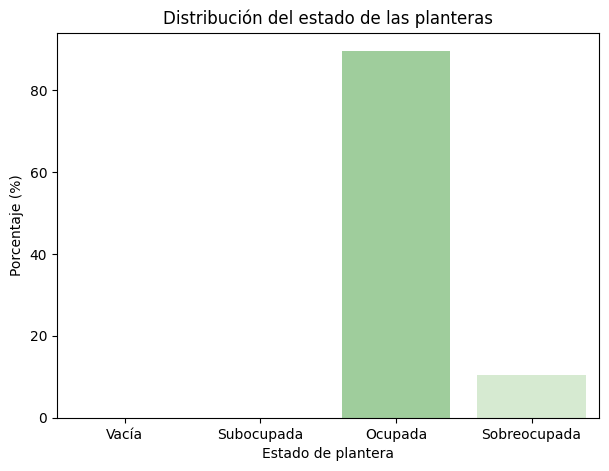

✅ Se rechaza H₀: la proporción de planteras sobreocupadas es significativa (p<0.000).
Interpretación: 10.37% de las planteras están sobreocupadas, superando el umbral del 5%.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

# Preparo los datos
df = arbolado[['estado_plantera']].dropna().copy()
df['estado_plantera'] = df['estado_plantera'].astype(int)

# Cuento planteras sobreocupadas
n_total = len(df)
n_sobre = (df['estado_plantera'] == 3).sum()
p_obs = n_sobre / n_total

print(f"Total de planteras: {n_total}")
print(f"Pl. sobreocupadas: {n_sobre} ({p_obs*100:.2f}%)")

# Test de hipótesis con H0: p <= 0.05 y H1: p > 0.05
stat, p_value = proportions_ztest(count=n_sobre, nobs=n_total, value=0.05, alternative='larger')

print(f"Estadístico z = {stat:.3f}")
print(f"p-valor = {p_value:.5f}")

# Visualización
frecuencias = df['estado_plantera'].value_counts().sort_index()
porcentajes = (frecuencias / frecuencias.sum()) * 100

plt.figure(figsize=(7,5))
sns.barplot(x=frecuencias.index, y=porcentajes, palette="Greens_r")
plt.xticks([0,1,2,3], ['Vacía', 'Subocupada', 'Ocupada', 'Sobreocupada'])
plt.title("Distribución del estado de las planteras")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Estado de plantera")
plt.show()

# Conclusión

if p_value < 0.05:
    print(f"✅ Se rechaza H₀: la proporción de planteras sobreocupadas es significativa (p<{p_value:.3f}).")
    print(f"Interpretación: {p_obs*100:.2f}% de las planteras están sobreocupadas, superando el umbral del 5%.")
else:
    print(f"❌ No se rechaza H₀: la proporción de planteras sobreocupadas NO es significativa (p={p_value:.3f}).")
    print(f"Interpretación: {p_obs*100:.2f}% de las planteras están sobreocupadas, dentro de los límites aceptables.")
